# Student Performance Analysis & Prediction

## Data Science & Machine Learning Project

**Dataset:** UCI Student Performance Dataset

**Objective:**  
To analyze the factors associated with student academic performance and build machine learning models to predict student outcomes.

### Models Used
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)

### Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1 Score
- Cohen's Kappa
- ROC-AUC
- Confusion Matrix

## 1. Project Objective

The main objectives of this project are:

1. Explore and understand the student performance dataset.
2. Identify factors associated with academic performance.
3. Analyze relationships between student characteristics, study habits, absences, and grades.
4. Predict student outcomes using machine learning classification models.
5. Compare different machine learning algorithms using multiple evaluation metrics.
6. Understand the importance of previous academic grades in predicting final outcomes.

## 2. Dataset Information

This project uses the UCI Student Performance Dataset.

The dataset contains information about students, including:

- Demographic information
- Family and social information
- Study habits
- Previous academic performance
- Absences
- Final academic grade

The dataset contains 649 student records and was collected from two Portuguese schools.

The analysis in this project focuses on the Mathematics dataset.

## 3. Import Libraries

The following Python libraries are used for data analysis, visualization, and machine learning.

- **Pandas** – data manipulation and analysis
- **NumPy** – numerical operations
- **Matplotlib** – data visualization
- **Seaborn** – statistical visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 4. Load Dataset

The Mathematics student performance dataset is loaded using Pandas. The dataset uses semicolon (`;`) as the separator between columns.

In [2]:
df = pd.read_csv("student-mat.csv", sep=";")

## 5. Data Understanding

Before performing analysis, the dataset is examined to understand its structure, columns, data types, and statistical properties.

In [3]:
print(df.head())
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]
(395, 33)
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu'

### 5.1 Missing Value Check

Missing values are checked to determine whether any data cleaning is required before analysis and model training.

In [4]:
print(df.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [5]:
print("Highest final grade:", df["G3"].max())
print("Lowest final grade:", df["G3"].min())

Highest final grade: 20
Lowest final grade: 0


## 6. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand patterns, relationships, and distributions within the student performance dataset.

### 6.1 Final Grade Distribution

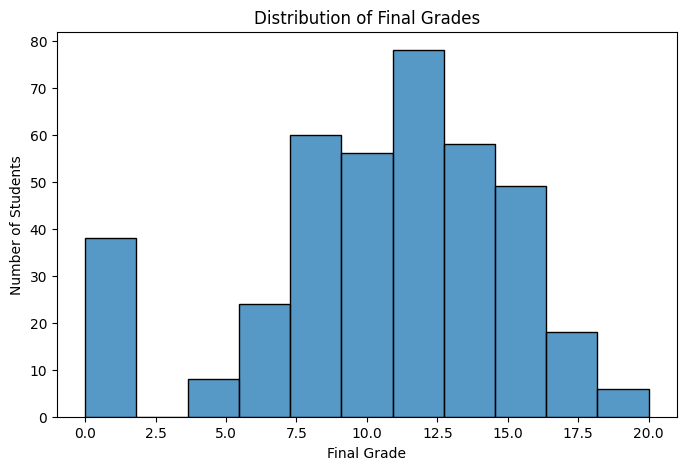

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(df["G3"], bins=11)

plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")

plt.show()

### 6.2 Study Time and Academic Performance

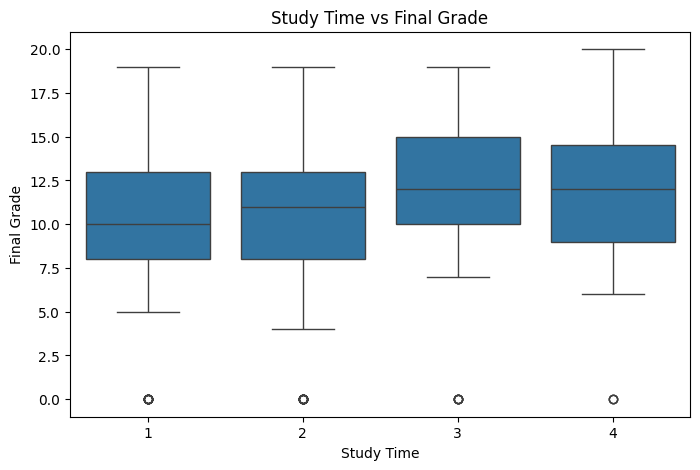

In [7]:
plt.figure(figsize=(8,5))

sns.boxplot(x="studytime", y="G3", data=df)

plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time")
plt.ylabel("Final Grade")

plt.show()

### 6.3 Absences and Academic Performance

### 6.4 Correlation Analysis

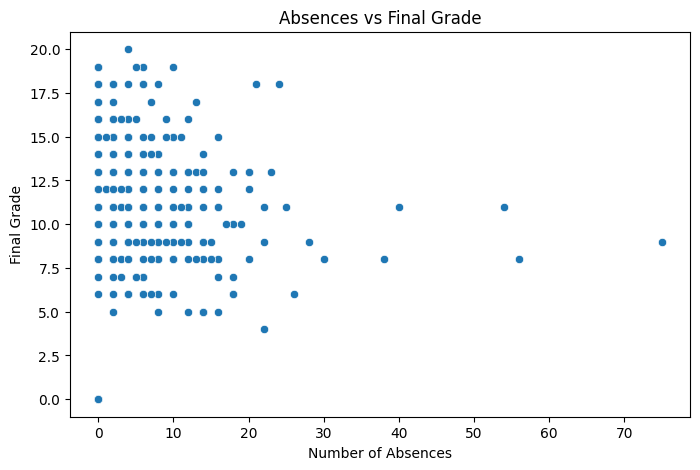

In [8]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="absences", y="G3", data=df)

plt.title("Absences vs Final Grade")
plt.xlabel("Number of Absences")
plt.ylabel("Final Grade")

plt.show()

In [9]:
print(df[["studytime", "failures", "absences", "G1", "G2", "G3"]].corr())

           studytime  failures  absences        G1        G2        G3
studytime   1.000000 -0.173563 -0.062700  0.160612  0.135880  0.097820
failures   -0.173563  1.000000  0.063726 -0.354718 -0.355896 -0.360415
absences   -0.062700  0.063726  1.000000 -0.031003 -0.031777  0.034247
G1          0.160612 -0.354718 -0.031003  1.000000  0.852118  0.801468
G2          0.135880 -0.355896 -0.031777  0.852118  1.000000  0.904868
G3          0.097820 -0.360415  0.034247  0.801468  0.904868  1.000000


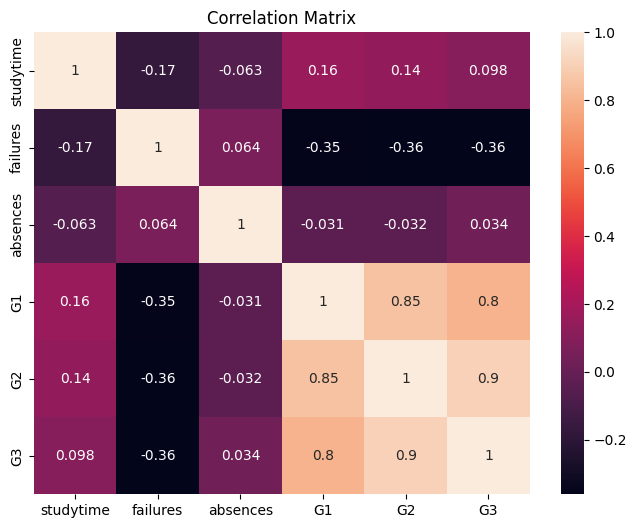

In [10]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[["studytime", "failures", "absences", "G1", "G2", "G3"]].corr(),
    annot=True
)

plt.title("Correlation Matrix")

plt.show()

In [11]:
# Target variable
y = df["G3"]

# Input variables
X = df.drop("G3", axis=1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (395, 32)
y shape: (395,)


In [12]:
X = pd.get_dummies(X, drop_first=True)

print(X.shape)
print(X.head())

(395, 41)
   age  Medu  Fedu  traveltime  studytime  failures  famrel  freetime  goout  \
0   18     4     4           2          2         0       4         3      4   
1   17     1     1           1          2         0       5         3      3   
2   15     1     1           1          2         3       4         3      2   
3   15     4     2           1          3         0       3         2      2   
4   16     3     3           1          2         0       4         3      2   

   Dalc  ...  guardian_mother  guardian_other  schoolsup_yes  famsup_yes  \
0     1  ...             True           False           True       False   
1     1  ...            False           False          False        True   
2     2  ...             True           False           True       False   
3     1  ...             True           False          False        True   
4     1  ...            False           False          False        True   

   paid_yes  activities_yes  nursery_yes  higher_yes

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (316, 41)
Testing data: (79, 41)


## 7. Regression Analysis

In this section, machine learning regression models are used to predict the student's final mathematics grade (G3).

The following regression models are evaluated:

- Linear Regression
- K-Nearest Neighbors (KNN) Regression
- Decision Tree Regression
- Random Forest Regression

The models are evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [15]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[ 6.00160699 11.52847844  2.86643677  8.79663116  8.55310627 11.88964112
 19.09674195  7.17307901  7.4050707  12.31153657]


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 1.6466656197147493
MSE: 5.656642833231217
R2 Score: 0.7241341236974024


In [17]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [18]:
rf_pred = rf_model.predict(X_test)

print(rf_pred[:10])

[ 8.32 11.78  6.5   9.76  8.8  12.86 18.7   6.72  6.68 13.33]


In [19]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest MSE:", rf_mse)
print("Random Forest R2 Score:", rf_r2)

Random Forest MAE: 1.1645569620253164
Random Forest MSE: 3.797716455696203
Random Forest R2 Score: 0.8147911386865877


In [20]:
print("Model Comparison")
print("-------------------------")

print("Linear Regression")
print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

print()

print("Random Forest")
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("R2:", rf_r2)

Model Comparison
-------------------------
Linear Regression
MAE: 1.6466656197147493
MSE: 5.656642833231217
R2: 0.7241341236974024

Random Forest
MAE: 1.1645569620253164
MSE: 3.797716455696203
R2: 0.8147911386865877


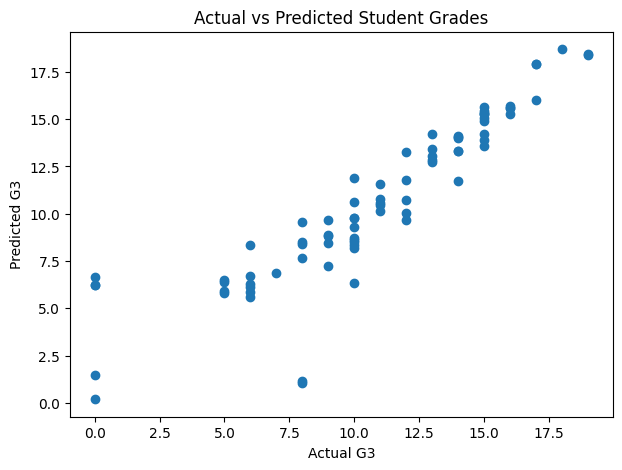

In [21]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted Student Grades")

plt.show()

## 8. Classification Analysis

The regression problem is extended into a binary classification problem.

Students are classified into two categories:

- **Pass:** G3 ≥ 10
- **Fail:** G3 < 10

Multiple classification algorithms are then compared using several evaluation metrics.

In [22]:
# Create Pass/Fail target

df["pass"] = df["G3"].apply(lambda x: 1 if x >= 10 else 0)

print(df[["G3", "pass"]].head(10))

   G3  pass
0   6     0
1   6     0
2  10     1
3  15     1
4  10     1
5  15     1
6  11     1
7   6     0
8  19     1
9  15     1


In [23]:
X_class = df.drop(["G3", "pass"], axis=1)

y_class = df["pass"]

X_class = pd.get_dummies(X_class, drop_first=True)

print("X shape:", X_class.shape)
print("y shape:", y_class.shape)

X shape: (395, 41)
y shape: (395,)


In [24]:
from sklearn.model_selection import train_test_split

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print("Training data:", X_train_class.shape)
print("Testing data:", X_test_class.shape)

Training data: (316, 41)
Testing data: (79, 41)


### 8.1 Logistic Regression

In [25]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_class, y_train_class)

log_pred = log_model.predict(X_test_class)

print("Logistic Regression predictions:")
print(log_pred[:10])

Logistic Regression predictions:
[1 0 1 1 1 1 1 0 1 1]


In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

log_accuracy = accuracy_score(y_test_class, log_pred)
log_precision = precision_score(y_test_class, log_pred)
log_recall = recall_score(y_test_class, log_pred)
log_f1 = f1_score(y_test_class, log_pred)

print("Accuracy:", log_accuracy)
print("Precision:", log_precision)
print("Recall:", log_recall)
print("F1 Score:", log_f1)

Accuracy: 0.8860759493670886
Precision: 0.9583333333333334
Recall: 0.8679245283018868
F1 Score: 0.9108910891089109


In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_class, log_pred)

print(cm)

[[24  2]
 [ 7 46]]


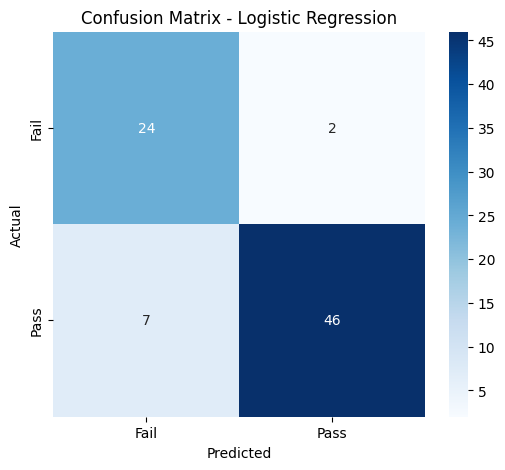

In [28]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [29]:
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(y_test_class, log_pred)

print("Cohen's Kappa:", kappa)

Cohen's Kappa: 0.7540643375994466


### 8.2 K-Nearest Neighbors (KNN)
### 8.3 Decision Tree
### 8.4 Random Forest
### 8.5 Support Vector Machine (SVM)

In [30]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# KNN
knn_class = KNeighborsClassifier(n_neighbors=5)
knn_class.fit(X_train_class, y_train_class)
knn_pred = knn_class.predict(X_test_class)

# Decision Tree
dt_class = DecisionTreeClassifier(random_state=42)
dt_class.fit(X_train_class, y_train_class)
dt_pred = dt_class.predict(X_test_class)

# Random Forest
rf_class = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_class.fit(X_train_class, y_train_class)
rf_pred_class = rf_class.predict(X_test_class)

# SVM
svm_class = SVC()
svm_class.fit(X_train_class, y_train_class)
svm_pred = svm_class.predict(X_test_class)

print("All classification models trained successfully!")

All classification models trained successfully!


## 9. Model Evaluation

The classification models are evaluated using multiple performance metrics to compare their predictive performance.

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score
)

models = {
    "Logistic Regression": log_pred,
    "KNN": knn_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred_class,
    "SVM": svm_pred
}

results = []

for name, predictions in models.items():

    accuracy = accuracy_score(y_test_class, predictions)
    precision = precision_score(y_test_class, predictions, zero_division=0)
    recall = recall_score(y_test_class, predictions, zero_division=0)
    f1 = f1_score(y_test_class, predictions, zero_division=0)
    kappa = cohen_kappa_score(y_test_class, predictions)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        kappa
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Kappa"
    ]
)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score     Kappa
0  Logistic Regression  0.886076   0.958333  0.867925  0.910891  0.754064
1                  KNN  0.860759   0.937500  0.849057  0.891089  0.699412
2        Decision Tree  0.860759   0.956522  0.830189  0.888889  0.704924
3        Random Forest  0.873418   0.957447  0.849057  0.900000  0.729267
4                  SVM  0.873418   0.921569  0.886792  0.903846  0.718861


### 9.1 Classification Metrics

### 9.3 Confusion Matrix

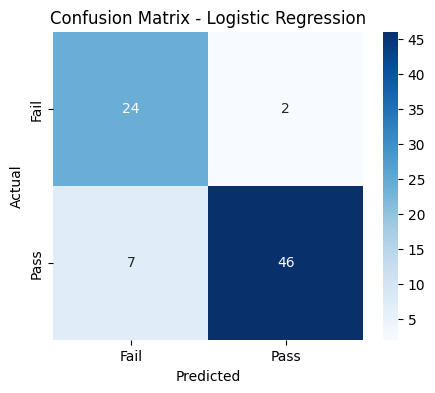

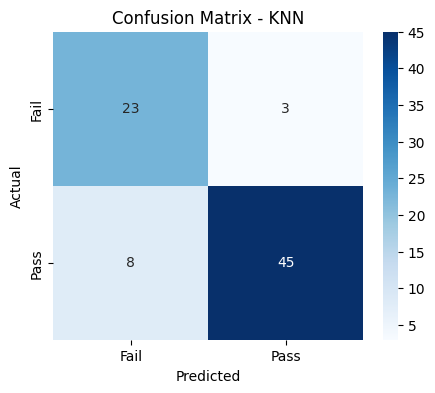

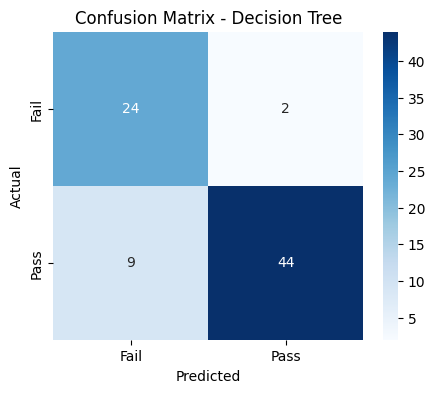

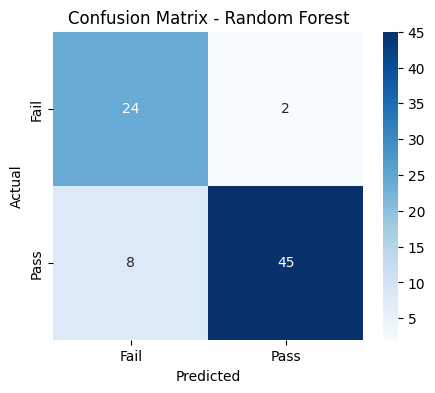

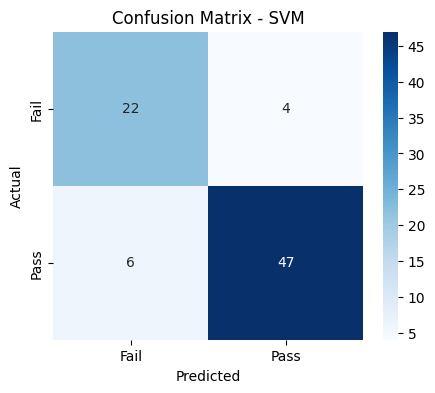

In [32]:
for name, predictions in models.items():

    cm = confusion_matrix(y_test_class, predictions)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Fail", "Pass"],
        yticklabels=["Fail", "Pass"]
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix - " + name)

    plt.show()

In [33]:
importance = rf_class.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X_class.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(15))

       Feature  Importance
14          G2    0.357823
13          G1    0.198104
5     failures    0.043452
12    absences    0.038176
8        goout    0.027756
0          age    0.025072
10        Walc    0.019552
11      health    0.017870
1         Medu    0.016358
2         Fedu    0.016341
6       famrel    0.015817
3   traveltime    0.014476
4    studytime    0.013899
9         Dalc    0.013628
7     freetime    0.013545


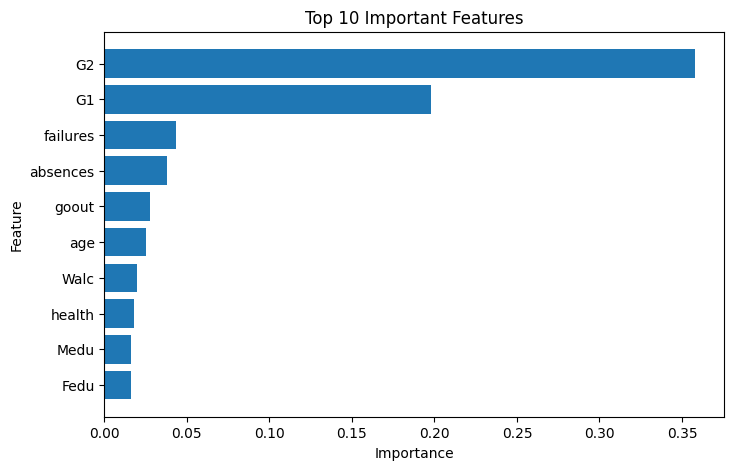

In [34]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [35]:
# Remove G1 and G2
X_no_grades = df.drop(["G3", "pass", "G1", "G2"], axis=1)

y_no_grades = df["pass"]

# Convert categorical variables
X_no_grades = pd.get_dummies(
    X_no_grades,
    drop_first=True
)

# Split the data
X_train_ng, X_test_ng, y_train_ng, y_test_ng = train_test_split(
    X_no_grades,
    y_no_grades,
    test_size=0.2,
    random_state=42,
    stratify=y_no_grades
)

print("Training data:", X_train_ng.shape)
print("Testing data:", X_test_ng.shape)

Training data: (316, 39)
Testing data: (79, 39)


### 9.6 Prediction With and Without Previous Grades

In [36]:
rf_no_grades = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_no_grades.fit(X_train_ng, y_train_ng)

rf_ng_pred = rf_no_grades.predict(X_test_ng)

In [37]:
ng_accuracy = accuracy_score(y_test_ng, rf_ng_pred)
ng_precision = precision_score(y_test_ng, rf_ng_pred, zero_division=0)
ng_recall = recall_score(y_test_ng, rf_ng_pred, zero_division=0)
ng_f1 = f1_score(y_test_ng, rf_ng_pred, zero_division=0)
ng_kappa = cohen_kappa_score(y_test_ng, rf_ng_pred)

print("Random Forest WITHOUT G1 and G2")
print("-------------------------------")
print("Accuracy:", ng_accuracy)
print("Precision:", ng_precision)
print("Recall:", ng_recall)
print("F1 Score:", ng_f1)
print("Kappa:", ng_kappa)

Random Forest WITHOUT G1 and G2
-------------------------------
Accuracy: 0.6835443037974683
Precision: 0.7058823529411765
Recall: 0.9056603773584906
F1 Score: 0.7933884297520661
Kappa: 0.15993194385367915


In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score
)

# Logistic Regression with scaling
log_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

log_scaled.fit(X_train_class, y_train_class)
log_scaled_pred = log_scaled.predict(X_test_class)


# KNN with scaling
knn_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_scaled.fit(X_train_class, y_train_class)
knn_scaled_pred = knn_scaled.predict(X_test_class)


# SVM with scaling
svm_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC())
])

svm_scaled.fit(X_train_class, y_train_class)
svm_scaled_pred = svm_scaled.predict(X_test_class)


# Function to calculate metrics
def calculate_metrics(name, y_true, predictions):

    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions, zero_division=0)
    recall = recall_score(y_true, predictions, zero_division=0)
    f1 = f1_score(y_true, predictions, zero_division=0)
    kappa = cohen_kappa_score(y_true, predictions)

    return [
        name,
        accuracy,
        precision,
        recall,
        f1,
        kappa
    ]


# Compare scaled models
scaled_results = []

scaled_results.append(
    calculate_metrics(
        "Logistic Regression",
        y_test_class,
        log_scaled_pred
    )
)

scaled_results.append(
    calculate_metrics(
        "KNN",
        y_test_class,
        knn_scaled_pred
    )
)

scaled_results.append(
    calculate_metrics(
        "SVM",
        y_test_class,
        svm_scaled_pred
    )
)


scaled_results_df = pd.DataFrame(
    scaled_results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Kappa"
    ]
)

print(scaled_results_df)

                 Model  Accuracy  Precision    Recall  F1 Score     Kappa
0  Logistic Regression  0.848101   0.936170  0.830189  0.880000  0.675120
1                  KNN  0.696203   0.723077  0.886792  0.796610  0.220395
2                  SVM  0.810127   0.851852  0.867925  0.859813  0.565775


In [39]:
final_results = [
    calculate_metrics(
        "Logistic Regression",
        y_test_class,
        log_scaled_pred
    ),

    calculate_metrics(
        "KNN",
        y_test_class,
        knn_scaled_pred
    ),

    calculate_metrics(
        "Decision Tree",
        y_test_class,
        dt_pred
    ),

    calculate_metrics(
        "Random Forest",
        y_test_class,
        rf_pred_class
    ),

    calculate_metrics(
        "SVM",
        y_test_class,
        svm_scaled_pred
    )
]

final_results_df = pd.DataFrame(
    final_results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Kappa"
    ]
)

print(final_results_df)

                 Model  Accuracy  Precision    Recall  F1 Score     Kappa
0  Logistic Regression  0.848101   0.936170  0.830189  0.880000  0.675120
1                  KNN  0.696203   0.723077  0.886792  0.796610  0.220395
2        Decision Tree  0.860759   0.956522  0.830189  0.888889  0.704924
3        Random Forest  0.873418   0.957447  0.849057  0.900000  0.729267
4                  SVM  0.810127   0.851852  0.867925  0.859813  0.565775


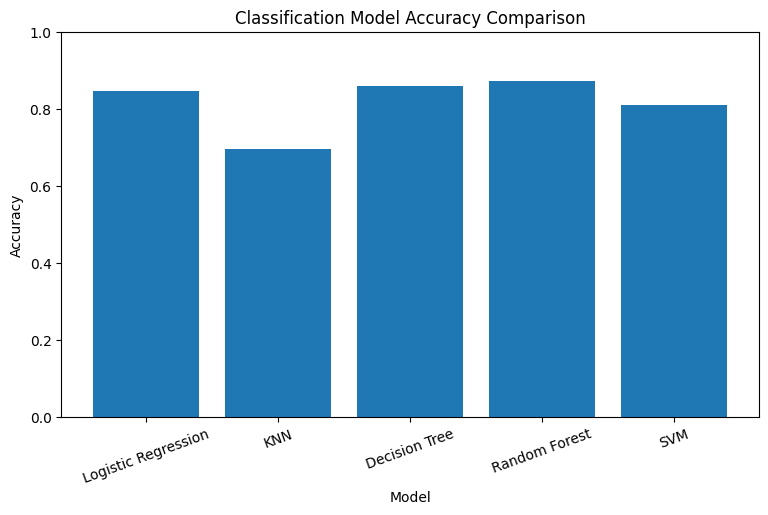

In [40]:
plt.figure(figsize=(9, 5))

plt.bar(
    final_results_df["Model"],
    final_results_df["Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Classification Model Accuracy Comparison")

plt.ylim(0, 1)

plt.xticks(rotation=20)

plt.show()

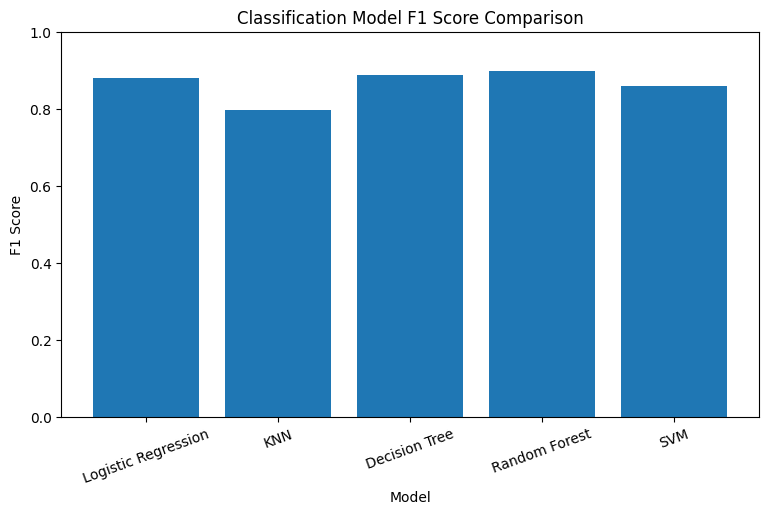

In [41]:
plt.figure(figsize=(9, 5))

plt.bar(
    final_results_df["Model"],
    final_results_df["F1 Score"]
)

plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.title("Classification Model F1 Score Comparison")

plt.ylim(0, 1)

plt.xticks(rotation=20)

plt.show()

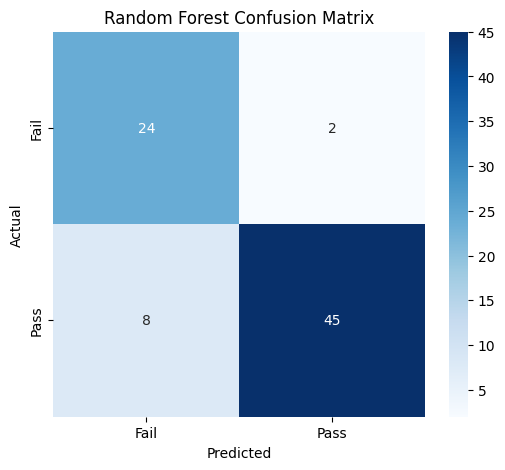

In [42]:
cm_rf = confusion_matrix(
    y_test_class,
    rf_pred_class
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

### 9.4 ROC-AUC Analysis

In [43]:
from sklearn.metrics import roc_auc_score

# Logistic Regression
log_prob = log_scaled.predict_proba(X_test_class)[:, 1]

# KNN
knn_prob = knn_scaled.predict_proba(X_test_class)[:, 1]

# Random Forest
rf_prob = rf_class.predict_proba(X_test_class)[:, 1]

# SVM
svm_score = svm_scaled.decision_function(X_test_class)

print("Logistic Regression ROC-AUC:",
      roc_auc_score(y_test_class, log_prob))

print("KNN ROC-AUC:",
      roc_auc_score(y_test_class, knn_prob))

print("Random Forest ROC-AUC:",
      roc_auc_score(y_test_class, rf_prob))

print("SVM ROC-AUC:",
      roc_auc_score(y_test_class, svm_score))

Logistic Regression ROC-AUC: 0.939767779390421
KNN ROC-AUC: 0.7449201741654572
Random Forest ROC-AUC: 0.9404934687953557
SVM ROC-AUC: 0.8940493468795356


In [44]:
print(final_results_df)

                 Model  Accuracy  Precision    Recall  F1 Score     Kappa
0  Logistic Regression  0.848101   0.936170  0.830189  0.880000  0.675120
1                  KNN  0.696203   0.723077  0.886792  0.796610  0.220395
2        Decision Tree  0.860759   0.956522  0.830189  0.888889  0.704924
3        Random Forest  0.873418   0.957447  0.849057  0.900000  0.729267
4                  SVM  0.810127   0.851852  0.867925  0.859813  0.565775


### 9.5 Feature Importance

In [45]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test_class, rf_pred_class)

print("Random Forest Confusion Matrix:")
print(cm_rf)

Random Forest Confusion Matrix:
[[24  2]
 [ 8 45]]


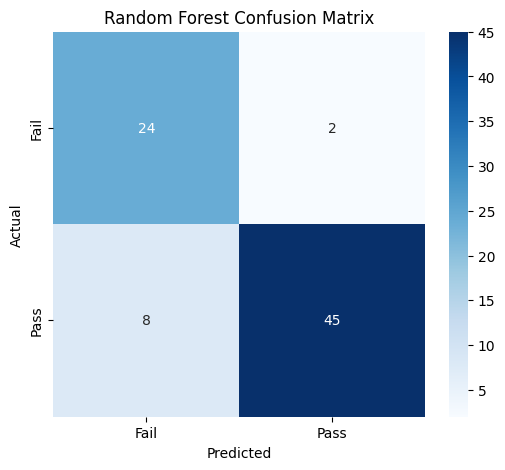

In [46]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

## 10. Conclusion

This project analyzed student academic performance using exploratory data analysis and machine learning techniques. Both regression and classification approaches were used to study and predict student outcomes.

The classification models were evaluated using multiple metrics, while feature importance was used to understand which variables provided the most predictive information.

## Final Findings

### 1. Academic performance is strongly related to previous grades
G1 and G2 were among the most important features in the Random Forest model. This indicates that previous-period academic performance provides strong predictive information about the final outcome.

### 2. Random Forest performed strongly
The Random Forest model achieved an accuracy of 87.34%, precision of 95.74%, recall of 84.91%, F1-score of 90.00%, and Cohen's Kappa of 0.7293.

### 3. Model performance varied across algorithms
The five classification models produced different results. KNN had lower overall accuracy, while Logistic Regression, Decision Tree, Random Forest, and SVM achieved higher accuracy on this test set.

### 4. The Random Forest confusion matrix
The Random Forest correctly classified 24 Fail cases and 45 Pass cases. It incorrectly classified 2 Fail cases as Pass and 8 Pass cases as Fail.

### 5. G1 and G2 have a major effect on prediction performance
When G1 and G2 were removed from the Random Forest model, accuracy decreased from 87.34% to 68.35%. This shows that previous grades contain substantial predictive information.

### 6. ROC-AUC
The ROC-AUC values were 0.9398 for Logistic Regression, 0.7449 for KNN, 0.9405 for Random Forest, and 0.8940 for SVM.

### Overall Conclusion
The analysis shows that previous academic performance is highly informative for predicting student outcomes in this dataset. Machine learning models were able to classify students into Pass and Fail categories with varying levels of performance. Random Forest achieved 87.34% accuracy and a 0.7293 Cohen's Kappa on the test set.

## Limitations

- The dataset contains students from two Portuguese schools, so the results may not generalize to students from other schools or countries.
- The dataset contains only 649 student records, which is relatively small for machine learning.
- G1 and G2 provide strong predictive information, but they are recorded before the final grade and may not be available in every prediction scenario.
- The model identifies statistical patterns and does not establish causal relationships between student characteristics and academic performance.
- Model performance can vary depending on the train-test split and other preprocessing choices.